# Day 19

---


In [1]:
import grama as gr
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
DF = gr.Intention()

# Set figure options
plt.rcParams['figure.figsize'] = [6, 6] # Need square aspect ratio for gradients to appear normal
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower


## Example: Multivariate Gaussian

In [2]:
md_gauss = (
    gr.Model("2d Gaussian")
    >> gr.cp_marginals(
        x=gr.marg_mom("norm", mean=0, sd=1),
        y=gr.marg_mom("norm", mean=0, sd=1),
    )
    >> gr.cp_copula_gaussian(
        df_corr=gr.df_make(
            var1="x", var2="y", corr=0.5,
        )
    )
)
md_gauss

/Users/zach/Git/py_grama/grama/marginals.py:338: RuntimeWarning: divide by zero encountered in scalar divide


model: 2d Gaussian

  inputs:
    var_det:

    var_rand:
      x: (+0) norm, {'mean': '0.000e+00', 's.d.': '1.000e+00', 'COV': inf, 'skew.': 0.0, 'kurt.': 3.0}
      y: (+0) norm, {'mean': '0.000e+00', 's.d.': '1.000e+00', 'COV': inf, 'skew.': 0.0, 'kurt.': 3.0}

    copula:
      Gaussian copula with correlations:
  var1 var2  corr
0    x    y   0.5

  functions:

Estimated runtime: 0.0000 sec


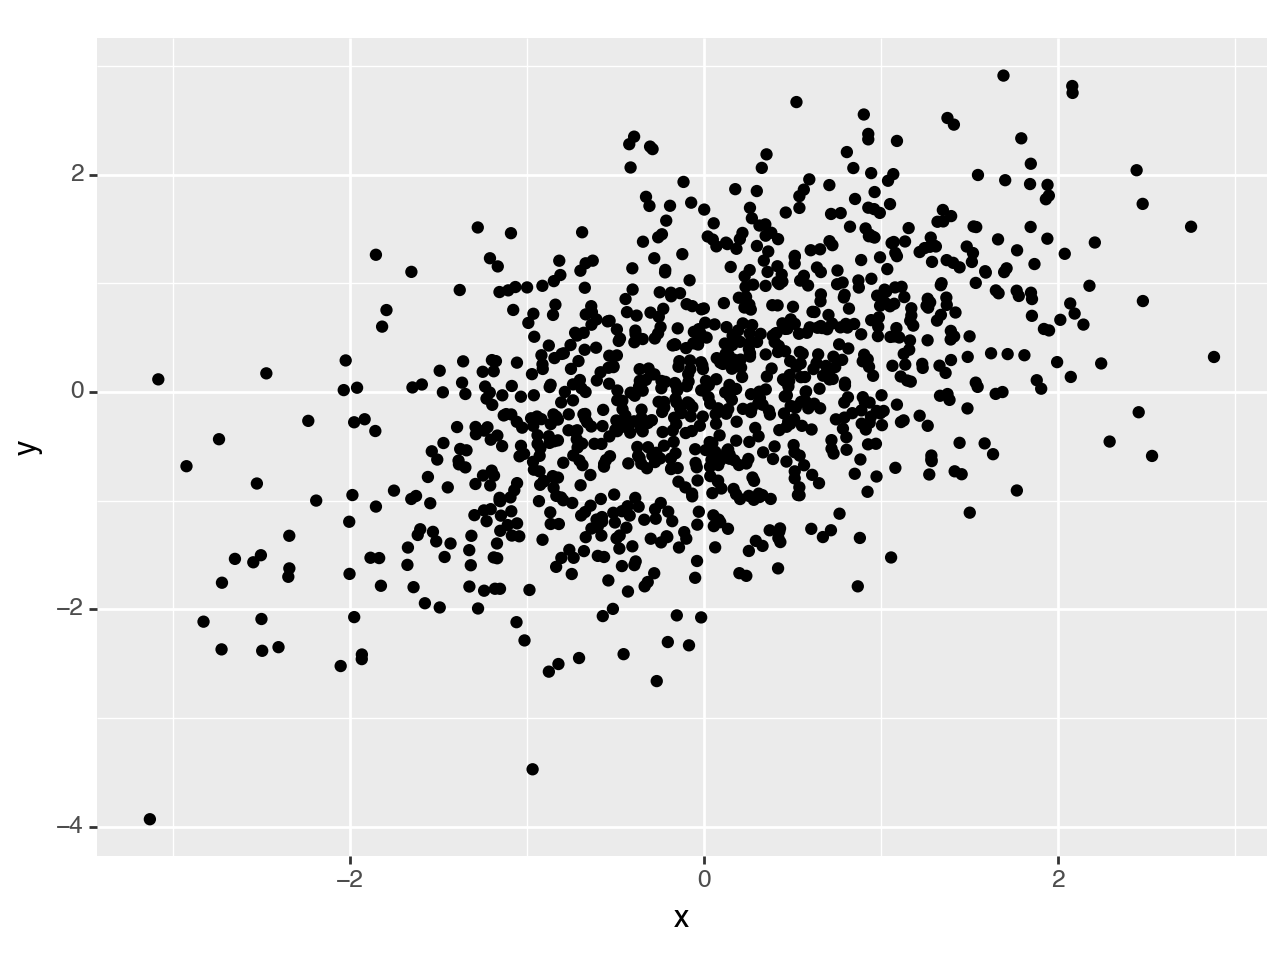

<Figure Size: (640 x 480)>

In [3]:
(
    md_gauss
    >> gr.ev_sample(df_det="nom", skip=True, n=1000)
    >> gr.ggplot(gr.aes("x", "y"))
    + gr.geom_point()
)

## Joint Density


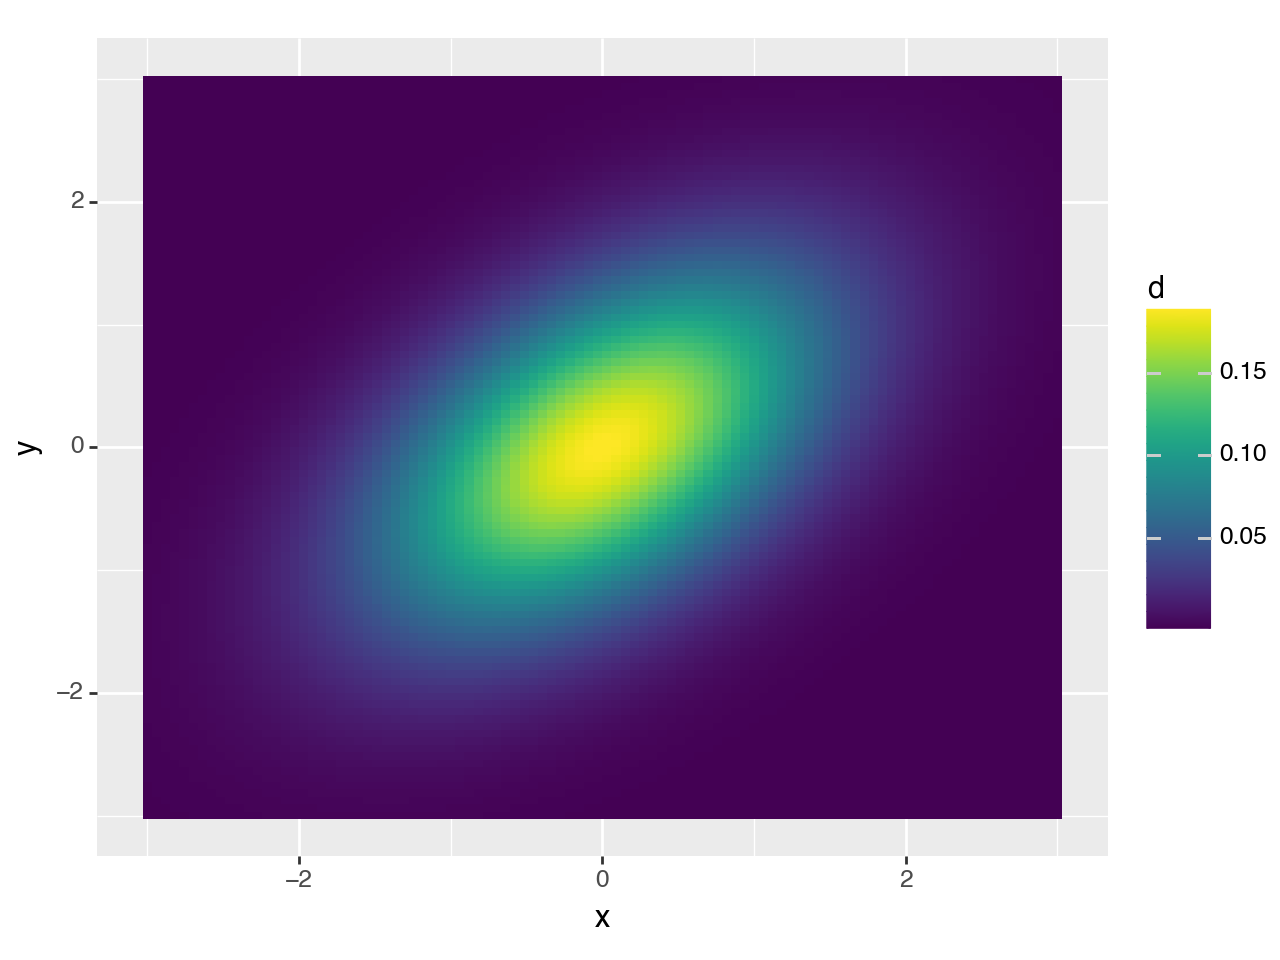

<Figure Size: (640 x 480)>

In [4]:
# Evaluate the joint density
df_2d = gr.df_grid(
    x=gr.linspace(-3, +3, 100),
    y=gr.linspace(-3, +3, 100),
)
df_2d['d'] = md_gauss.density.d(df_2d[["x", "y"]])

# Plot
(
    df_2d
    >> gr.ggplot(gr.aes("x", "y"))
    + gr.geom_tile(gr.aes(fill="d"))
)

## Marginals

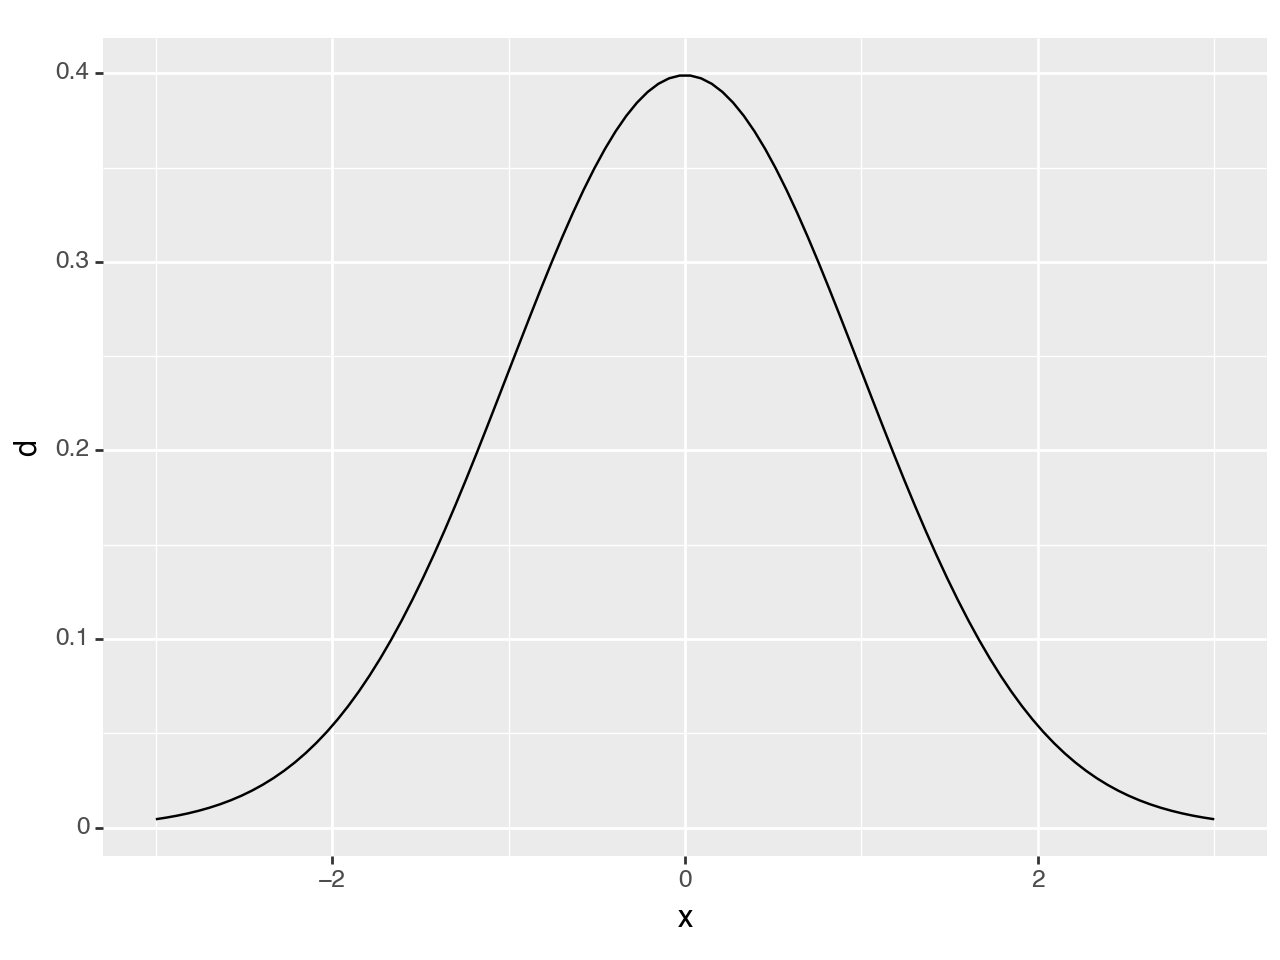

<Figure Size: (640 x 480)>

In [5]:
(
    gr.df_make(x=gr.linspace(-3, +3, 100))
    >> gr.tf_mutate(
        d=md_gauss.density.marginals["x"].d(DF.x)
    )

    >> gr.ggplot(gr.aes("x", "d"))
    + gr.geom_line()
)